# Backpropagation — a beginner's walkthrough

*Companion to the ResNet notes.* The previous notebook showed that a gradient is
a **product of per-layer factors**. But where do those factors *come from*?
The answer is **backpropagation** — the algorithm that computes gradients and
lets a network learn.

We'll build it up from nothing:

1. **What "learning" even means** — a knob, an error, and a direction.
2. **The gradient** — which way to turn the knob (by hand, then by calculus).
3. **The chain rule** — backprop's one and only trick.
4. **A tiny network, fully by hand** — forward pass, then backward pass.
5. **Watch it learn** — train it and plot the loss going down.

No frameworks — just `numpy` so every step is visible.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. What does "learning" mean?

A network has **knobs** (called *weights*). Learning = turning the knobs so the
output gets closer to the right answer.

Start with the smallest possible example: one knob `w`. The network just
multiplies its input by `w`:  `prediction = w * x`. We want it to learn the
rule `y = 2 * x` — i.e. discover that `w` should be `2`.

To measure "how wrong," we use a **loss**: the squared error
`(prediction - target)²`. Small loss = good. Let's see the loss for many
values of `w`.

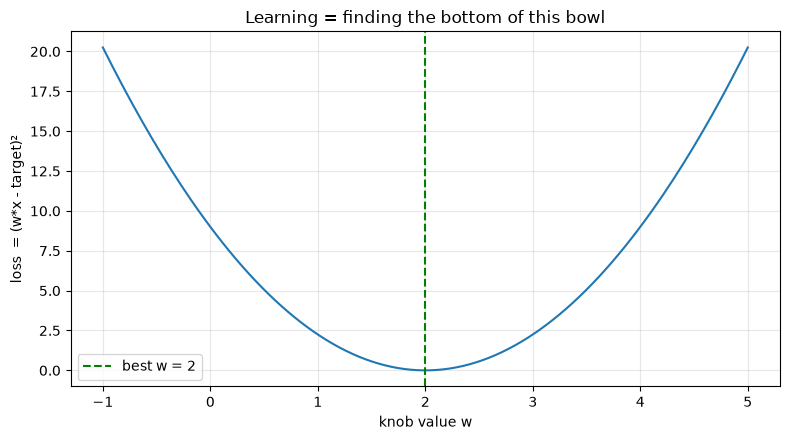

In [2]:
x, target = 1.5, 3.0          # one example: input 1.5, correct answer 3.0 (=2*1.5)

w_values = np.linspace(-1, 5, 200)
loss = (w_values * x - target) ** 2

plt.figure()
plt.plot(w_values, loss)
plt.axvline(2.0, color="g", ls="--", label="best w = 2")
plt.xlabel("knob value w")
plt.ylabel("loss  = (w*x - target)²")
plt.title("Learning = finding the bottom of this bowl")
plt.legend()
plt.tight_layout(); plt.show()

The loss is a **bowl**. Learning means rolling down to the bottom (`w = 2`).
The catch: the network can't *see* this whole curve — it only knows the loss at
its **current** `w`. So it needs a way to know **which direction is downhill**
from where it stands. That direction is the **gradient**.

## 2. The gradient = the downhill direction

The gradient is the **slope** of the loss with respect to the knob:
"if I nudge `w` up a tiny bit, does the loss go up or down, and how fast?"

- slope **positive** → loss rises if we increase `w` → so move `w` **down**
- slope **negative** → loss falls if we increase `w` → so move `w` **up**

Either way: **step in the opposite direction of the slope.** That's
*gradient descent.* First let's measure the slope the dumb way — just nudge `w`
and see how the loss changes (a finite difference).

In [3]:
def loss_at(w):
    return (w * x - target) ** 2

def slope_numeric(w, h=1e-5):
    return (loss_at(w + h) - loss_at(w - h)) / (2 * h)   # rise / run

for w in [0.0, 1.0, 2.0, 3.5]:
    s = slope_numeric(w)
    move = "increase w" if s < 0 else "decrease w"
    print(f"w={w:>4}:  loss={loss_at(w):5.2f}   slope={s:+6.2f}  -> {move}")

w= 0.0:  loss= 9.00   slope= -9.00  -> increase w
w= 1.0:  loss= 2.25   slope= -4.50  -> increase w
w= 2.0:  loss= 0.00   slope= +0.00  -> decrease w
w= 3.5:  loss= 5.06   slope= +6.75  -> decrease w


At `w=0` the slope is negative → we should *increase* `w` (toward 2). ✔
At `w=3.5` the slope is positive → we should *decrease* `w` (back toward 2). ✔
At `w=2` the slope is ~0 → we're at the bottom, stop. ✔

Nudging works but is slow (one probe per knob). **Calculus** gives the slope
directly. For `loss = (w*x - target)²`, the chain rule says:

$$\frac{d\,\text{loss}}{dw} = 2\,(w x - \text{target}) \cdot x$$

Let's confirm the formula matches the nudge.

In [4]:
def slope_formula(w):
    return 2 * (w * x - target) * x

for w in [0.0, 1.0, 2.0, 3.5]:
    print(f"w={w:>4}:  numeric={slope_numeric(w):+7.4f}   formula={slope_formula(w):+7.4f}")

w= 0.0:  numeric=-9.0000   formula=-9.0000
w= 1.0:  numeric=-4.5000   formula=-4.5000
w= 2.0:  numeric=+0.0000   formula=+0.0000
w= 3.5:  numeric=+6.7500   formula=+6.7500


Identical. The formula is what real networks use — it's exact and cheap. Now let's roll down the bowl: repeatedly `w = w - step * slope`. 

**But why scale the step by the slope instead of moving a constant amount?** 

The slope carries two things at once — **direction** (its sign) and **distance** (its size) — 
and the size is what lets descent *stop*: the slope shrinks to zero at the bottom, so a
slope-scaled step **eases in and settles** there, while a constant-size step (sign
only, for direction) has nothing to slow it down and **jitters** around the minimum
forever. Same bowl, same start — watch the difference.

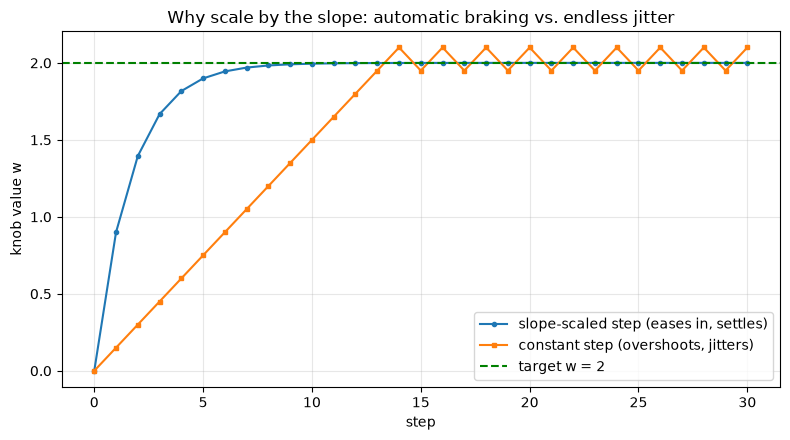

slope-scaled: last 3 w = [2.0, 2.0, 2.0]  <- settled
constant    : last 3 w = [2.1, 1.95, 2.1]  <- bounces, never settles


In [5]:
start, n_steps = 0.0, 30
lr = 0.1          # slope-scaled: step = lr * slope
c  = 0.15         # constant: step is always this size, only its sign changes

w_scaled = [start]; w = start
for _ in range(n_steps):
    w = w - lr * slope_formula(w)            # step shrinks as the slope shrinks
    w_scaled.append(w)

w_const = [start]; w = start
for _ in range(n_steps):
    w = w - c * np.sign(slope_formula(w))    # same size every step, only sign varies
    w_const.append(w)

plt.figure()
plt.plot(w_scaled, marker="o", ms=3, label="slope-scaled step (eases in, settles)")
plt.plot(w_const,  marker="s", ms=3, label="constant step (overshoots, jitters)")
plt.axhline(2.0, color="g", ls="--", label="target w = 2")
plt.xlabel("step"); plt.ylabel("knob value w")
plt.title("Why scale by the slope: automatic braking vs. endless jitter")
plt.legend()
plt.tight_layout(); plt.show()

print(f"slope-scaled: last 3 w = {[round(float(v), 4) for v in w_scaled[-3:]]}  <- settled")
print(f"constant    : last 3 w = {[round(float(v), 4) for v in w_const[-3:]]}  <- bounces, never settles")

The blue curve *is* the learning loop in action — the knob rolls to `w = 2`
and stops. That's it, with **one** knob. A real network has
millions of knobs — and backprop is how we get the slope for **every** knob
efficiently in a single backward pass. The engine behind it is the chain rule.

## 3. The chain rule (backprop's only trick)

Networks are **functions inside functions**. A value flows: `w → z → a → loss`.
To learn `w`, we need `d loss / d w`. The **chain rule** says: multiply the
slopes of each step along the path.

$$\frac{d\,\text{loss}}{dw}
 = \frac{d\,\text{loss}}{da}\cdot\frac{da}{dz}\cdot\frac{dz}{dw}$$

**That is backpropagation.** "Back" = we compute these from the *output end*
backward to the input, reusing each result for the next step so nothing is
recomputed. Each factor in that product is exactly the "per-layer factor" from
the gradient notebook — now you know where they come from.

Let's use it on a network with a nonlinearity in the middle.

## 4. A tiny network, fully by hand

Our network, one path:

```
z = w * x        (weighted input)
a = tanh(z)      (activation / nonlinearity)
pred = v * a     (output weight)
loss = (pred - target)²
```

Two knobs now: `w` and `v`. We'll do the **forward pass** (compute the loss),
then the **backward pass** (chain-rule the slope for each knob), and check both
against the nudge method.

In [6]:
x, target = 0.8, 1.0

def forward(w, v):
    z = w * x
    a = np.tanh(z)
    pred = v * a
    loss = (pred - target) ** 2
    return loss, (z, a, pred)

def backward(w, v):
    loss, (z, a, pred) = forward(w, v)
    # walk backward, multiplying local slopes (the chain rule)
    dpred = 2 * (pred - target)     # d loss / d pred
    dv    = dpred * a               # d loss / d v   (since pred = v*a)
    da    = dpred * v               # d loss / d a
    dz    = da * (1 - np.tanh(z)**2)# through tanh:  da/dz = 1 - tanh(z)²
    dw    = dz * x                  # d loss / d w   (since z = w*x)
    return dw, dv

w, v = 0.5, -0.3
dw, dv = backward(w, v)

# sanity-check against nudging each knob
def ndiff(f, val, h=1e-6):
    return (f(val + h) - f(val - h)) / (2*h)
dw_num = ndiff(lambda ww: forward(ww, v)[0], w)
dv_num = ndiff(lambda vv: forward(w, vv)[0], v)

print(f"d loss / d w :  backprop={dw:+.6f}   nudge={dw_num:+.6f}")
print(f"d loss / d v :  backprop={dv:+.6f}   nudge={dv_num:+.6f}")

d loss / d w :  backprop=+0.457521   nudge=+0.457521
d loss / d v :  backprop=-0.846515   nudge=-0.846515


Backprop matches the nudge for **both** knobs — but backprop got them together
in one backward sweep, while nudging needed a separate probe per knob. With a
million knobs that difference is everything. **This efficiency is why backprop,
not brute-force nudging, powers deep learning.**

## 5. Watch it learn

Now train those two knobs on a small dataset so the network learns a real
input→output mapping, and plot the loss falling.

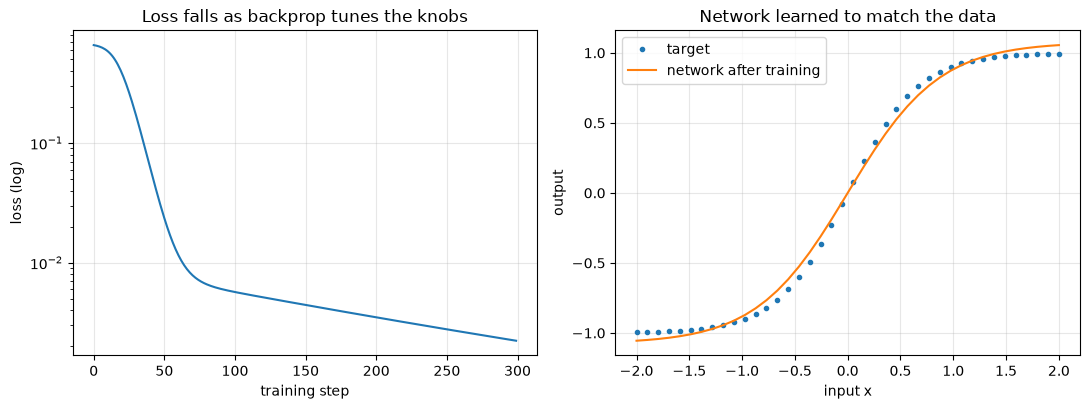

learned w=1.158, v=1.076;  final loss=0.00223


In [7]:
rng = np.random.default_rng(0)
# dataset: target y = tanh(1.5 * x) pattern, a few points
xs = np.linspace(-2, 2, 40)
ys = np.tanh(1.5 * xs)

def fwd(w, v, xb):        # vectorized forward over a batch
    a = np.tanh(w * xb)
    return v * a, a

w, v, lr = 0.1, 0.1, 0.05
losses = []
for epoch in range(300):
    pred, a = fwd(w, v, xs)
    err = pred - ys
    losses.append(np.mean(err**2))
    # backprop, averaged over the batch
    dpred = 2 * err / len(xs)
    dv = np.sum(dpred * a)
    dz = dpred * v * (1 - a**2)
    dw = np.sum(dz * xs)
    w -= lr * dw
    v -= lr * dv

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(losses); ax1.set_yscale("log")
ax1.set_xlabel("training step"); ax1.set_ylabel("loss (log)")
ax1.set_title("Loss falls as backprop tunes the knobs")
ax2.plot(xs, ys, "o", ms=3, label="target")
ax2.plot(xs, fwd(w, v, xs)[0], "-", label="network after training")
ax2.set_xlabel("input x"); ax2.set_ylabel("output")
ax2.set_title("Network learned to match the data")
ax2.legend()
plt.tight_layout(); plt.show()
print(f"learned w={w:.3f}, v={v:.3f};  final loss={losses[-1]:.5f}")

**Left:** the loss drops steadily — each step, backprop points every knob
downhill. **Right:** the network's curve lands on the target data.

### Recap
- **Learning** = roll the loss downhill by turning knobs (weights).
- The **gradient** is the downhill direction (the slope of loss vs. each knob).
- **Backpropagation** computes every knob's slope in one backward pass using the
  **chain rule** — multiplying local slopes from the output back to the input.
- Those multiplied local slopes are exactly the per-layer factors that can
  **vanish or explode** in deep nets — the problem the ResNet notebook explored,
  and the reason skip connections matter.

*Try it:* change `lr` (too big → loss diverges, too small → crawls), add a
third knob/layer, or swap `tanh` for another activation and re-derive its
local slope.